In [28]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import math

In [29]:
def draw_hough_lines(edge_image, threshold, line_length_scale):

    #detecta linhas rho, theta
    lines = cv.HoughLines(edge_image, 1, np.pi / 180, threshold, 0, 0)

    output_img = cv.cvtColor(edge_image, cv.COLOR_GRAY2BGR)

    if lines is not None:
        for line in lines:
            rho, theta = line[0]
            a = math.cos(theta)
            b = math.sin(theta)
            x0 = a * rho
            y0 = b * rho
            pt1 = (int(x0 + line_length_scale * (-b)), int(y0 + line_length_scale * (a)))
            pt2 = (int(x0 - line_length_scale * (-b)), int(y0 - line_length_scale * (a)))
            cv.line(output_img, pt1, pt2, (0, 0, 255), 3, cv.LINE_AA)

    return output_img

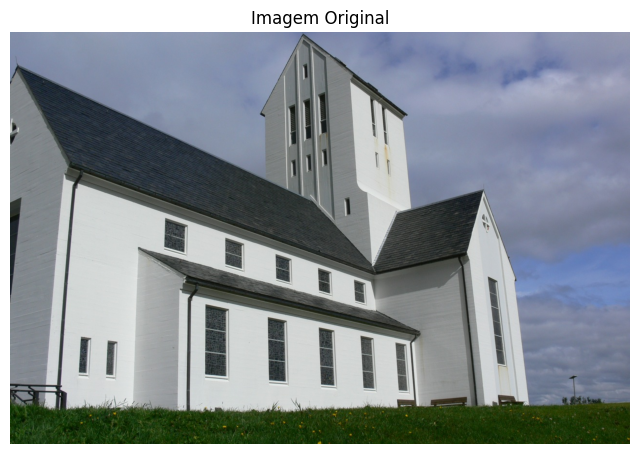

In [30]:
img = cv.imread('church.jpg')

if img is None:
    raise FileNotFoundError("Nao foi possivel ler a imagem")

plt.figure(figsize=(8, 6))
plt.title("Imagem Original")
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.axis('off')
plt.show()
dst = cv.Canny(img, 50, 200, None, 3)

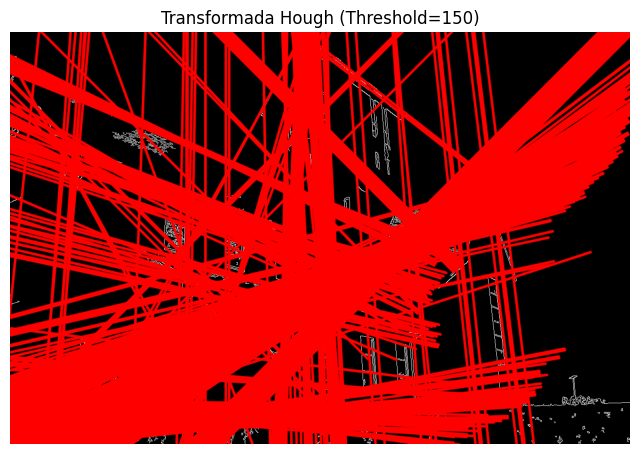

In [31]:
result1 = draw_hough_lines(dst, threshold=150, line_length_scale=1000)

plt.figure(figsize=(8, 6))
plt.title("Transformada Hough (Threshold=150)")
plt.imshow(cv.cvtColor(result1, cv.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

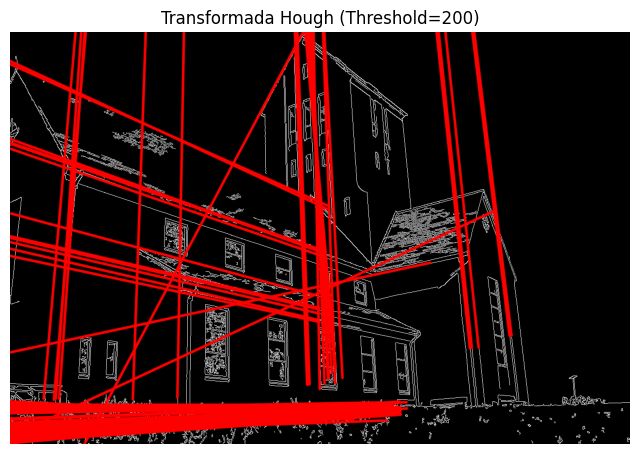

In [32]:
result2 = draw_hough_lines(dst, threshold=200, line_length_scale=750)

plt.figure(figsize=(8, 6))
plt.title("Transformada Hough (Threshold=200)")
plt.imshow(cv.cvtColor(result2, cv.COLOR_BGR2RGB))
plt.axis('off')
plt.show()